In [1]:
import gym
import imageio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display, Image
from PIL import Image as PILImage
import io

# 定義操作對應的文字
# 0: Left, 1: Down, 2: Right, 3: Up
action_map = {
    0: "Left",
    1: "Down",
    2: "Right",
    3: "Up"
}

def run_episode_and_capture_frames(env, policy):
    """
    執行一個 episode 並捕捉每一幀的畫面。

    Args:
        env: gym 環境實例。
        policy: 策略函數，接受狀態並返回動作。

    Returns:
        frames: 捕捉到的畫面列表 (numpy array)。
        reward: 最終獲得的獎勵。
        done: episode 是否結束。
    """
    frames = []
    state, info = env.reset()
    done = False
    reward = 0

    print("--- 開始模擬 ---")
    print(f"初始狀態: {state}")

    while not done:
        # 根據當前狀態選擇動作
        action = policy[state]
        print(f"當前狀態: {state}, 選擇動作: {action} ({action_map.get(action, 'Unknown')})")

        # 捕捉當前畫面
        frame = env.render()
        frames.append(frame)

        # 執行操作
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated # 判斷 episode 是否結束
        print(f"操作 {action} ({action_map.get(action, 'Unknown')}) -> 新狀態 {next_state}, 獎勵 {reward}, 結束 {done}")
        state = next_state


    # 捕捉最終畫面 (如果 episode 結束)
    if done:
         frame = env.render()
         frames.append(frame)
         print(f"模擬結束。最終獎勵: {reward}")
    elif not done and len(actions) > 0:
         # 如果提供了操作但 episode 未結束，捕捉最後一個狀態的畫面
         frame = env.render()
         frames.append(frame)
         print(f"模擬完成所有 {len(actions)} 個操作。Episode 未結束。最終狀態: {state}")
    elif len(actions) == 0:
         # 如果沒有提供操作，只捕捉初始畫面
         frame = env.render()
         frames.append(frame)
         print("沒有提供操作。只顯示初始狀態。")


    return frames, reward, done

def create_gif_from_frames(frames, filename='frozenlake.gif', fps=4):
    """
    將 frames 儲存為 GIF，並回傳檔案名稱。
    """
    # frames 為 ndarray list，shape=(H,W,3)
    imageio.mimsave(filename, frames, fps=fps) # 儲存為 GIF，fps 為每秒幀數，這裡設為 4，即每幀顯示 0.25 秒。
    return filename

def display_gif_in_notebook(filename="frozen_lake_episode.gif"):
    """
    在 Jupyter Notebook 中顯示 GIF 動畫。

    Args:
        filename: 要顯示的 GIF 檔案名稱。
    """
    try:
        display(Image(filename=filename, format='gif'))
    except FileNotFoundError:
        print(f"錯誤：找不到檔案 {filename}。")

In [2]:
import gym

"""建立 FrozenLake-v1 環境，使用預設的並建立隨機環境。這裡使用 is_slippery=False 來模擬一個確定性的環境"""
# 建立 FrozenLake-v1 環境，使用預設的並建立隨機環境
# 這裡使用 is_slippery=False 來模擬一個確定性的環境
env = gym.make('FrozenLake-v1', is_slippery=False, render_mode='rgb_array', map_name="4x4")

env.reset()
# 定義一個簡單的操作序列，這裡假設玩家依次向下、向右、向上、向左移動
actions = [1, 2, 3, 0]  # Down, Right, Up, Left

state = 0  # 起始狀態
action = 1 # 嘗試向左移動 (LEFT)

transition_info = env.P[state][action] # 獲取狀態轉移資訊
# 獲取轉移資訊的詳細內容
# 這裡的 transition_info 是一個列表，包含了 (probability, next_state, reward, done) 的元組
for prob, next_state, reward, done in transition_info:
    print(f"轉移機率: {prob}, 下一狀態: {next_state}, 獎勵: {reward}, 結束: {done}")

# 關閉環境
env.close()


"""建立 FrozenLake-v1 環境，使用預設的並建立隨機環境。這裡使用 is_slippery=True 來模擬一個隨機性的環境"""
# 建立 FrozenLake-v1 環境，使用預設的並建立隨機環境
# 這裡使用 is_slippery=True 來模擬一個隨機的環境
env = gym.make('FrozenLake-v1', is_slippery=True, render_mode='rgb_array', map_name="4x4")
# is_slippery=True 會使得環境的行為變得隨機化，這樣玩家在移動時可能會滑到其他位置
# 這樣的設置可以用來測試強化學習演算法在隨機環境中的表現

env.reset()
# 定義一個簡單的操作序列，這裡假設玩家依次向下、向右、向上、向左移動
actions = [1, 2, 3, 0]  # Down, Right, Up, Left

state = 0  # 起始狀態
action = 1 # 嘗試向左移動 (LEFT)

transition_info = env.P[state][action] # 獲取狀態轉移資訊
# 獲取轉移資訊的詳細內容
# 這裡的 transition_info 是一個列表，包含了 (probability, next_state, reward, done) 的元組
for prob, next_state, reward, done in transition_info:
    print(f"轉移機率: {prob}, 下一狀態: {next_state}, 獎勵: {reward}, 結束: {done}")

# 關閉環境
env.close()

轉移機率: 1.0, 下一狀態: 4, 獎勵: 0.0, 結束: False
轉移機率: 0.3333333333333333, 下一狀態: 0, 獎勵: 0.0, 結束: False
轉移機率: 0.3333333333333333, 下一狀態: 4, 獎勵: 0.0, 結束: False
轉移機率: 0.3333333333333333, 下一狀態: 1, 獎勵: 0.0, 結束: False


執行 episode 中...
--- 開始模擬 ---
初始狀態: 0
當前狀態: 0, 選擇動作: 1 (Down)
操作 1 (Down) -> 新狀態 4, 獎勵 0.0, 結束 False
當前狀態: 4, 選擇動作: 1 (Down)
操作 1 (Down) -> 新狀態 8, 獎勵 0.0, 結束 False
當前狀態: 8, 選擇動作: 2 (Right)
操作 2 (Right) -> 新狀態 9, 獎勵 0.0, 結束 False
當前狀態: 9, 選擇動作: 1 (Down)
操作 1 (Down) -> 新狀態 13, 獎勵 0.0, 結束 False
當前狀態: 13, 選擇動作: 2 (Right)
操作 2 (Right) -> 新狀態 14, 獎勵 0.0, 結束 False
當前狀態: 14, 選擇動作: 2 (Right)
操作 2 (Right) -> 新狀態 15, 獎勵 1.0, 結束 True
模擬結束。最終獎勵: 1.0
Episode 結束，done=True，總 reward=1.0
GIF 已儲存至 frozenlake_not_slippery.gif，以下在 Notebook 中顯示：


c:\Users\jhbai\Anaconda\envs\MachineLearningEnv\Lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


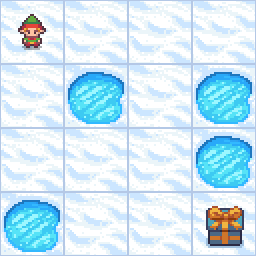

In [ ]:
import gym
import numpy as np
from IPython.display import HTML
from base64 import b64encode

def value_iteration(env, gamma=0.95, theta=1e-6): # gamma: 折扣因子, theta: 收斂閾值
    from Value_Iteration import Method as VI
    return VI(env.P, env.observation_space.n, env.action_space.n, gamma, theta) # 使用 Value Iteration 方法計算最優值函數和最優策略

if __name__ == "__main__":
    # --- 建立環境 ---
    env = gym.make('FrozenLake-v1', render_mode='rgb_array', is_slippery=False) 
    # render_mode意思是使用 rgb_array 模式來捕捉畫面，捕捉畫面後會儲存在 env.render() 的回傳值中。
    # 捕捉畫面的意思是將環境的畫面轉換為 RGB 格式的 numpy array，這樣可以方便地將畫面儲存為 GIF 動畫。
    # 這裡使用 is_slippery=False 來模擬一個確定性的環境，這樣可以讓 agent 更容易學習到最優策略。

    env.reset() # 重置環境，獲取初始狀態

    # 用 Value Iteration 訓練
    V, policy = value_iteration(env, gamma=0.9, theta=1e-6)

    # 自動執行最優策略
    policy_or_actions = policy # 將 numpy array 轉換為 list，這樣可以方便地傳遞給 run_episode_and_capture_frames 函數

    # 執行 episode 並捕捉畫面
    print("執行 episode 中...")
    frames, final_reward, done = run_episode_and_capture_frames(env, policy_or_actions)
    print(f"Episode 結束，done={done}，總 reward={final_reward}")

    # --- 4. 建立並顯示 GIF 動畫 ---
    if frames:
        gif_path = create_gif_from_frames(frames, filename='frozenlake_not_slippery.gif', fps=4)
        print(f"GIF 已儲存至 {gif_path}，以下在 Notebook 中顯示：")
        display_html = display_gif_in_notebook(gif_path)
        display_html  # 在 Notebook 中顯示

    env.close()


In [13]:
policy

[0.5904900000000002,
 0.6561000000000001,
 0.7290000000000001,
 0.6561000000000001,
 0.6561000000000001,
 0.0,
 0.81,
 0.0,
 0.7290000000000001,
 0.81,
 0.9,
 0.0,
 0.0,
 0.9,
 1.0,
 0.0]

正在執行 Value Iteration (slippery=True) …
訓練完成，最優策略 (0:Left,1:Down,2:Right,3:Up)：
[0, 3, 0, 3, 0, 0, 0, 0, 3, 1, 0, 0, 0, 2, 1, 0]
使用最優策略執行一個 episode …
--- 開始模擬 ---
初始狀態: 0
當前狀態: 0, 選擇動作: 0 (Left)
操作 0 (Left) -> 新狀態 0, 獎勵 0.0, 結束 False
當前狀態: 0, 選擇動作: 0 (Left)
操作 0 (Left) -> 新狀態 0, 獎勵 0.0, 結束 False
當前狀態: 0, 選擇動作: 0 (Left)
操作 0 (Left) -> 新狀態 0, 獎勵 0.0, 結束 False
當前狀態: 0, 選擇動作: 0 (Left)
操作 0 (Left) -> 新狀態 0, 獎勵 0.0, 結束 False
當前狀態: 0, 選擇動作: 0 (Left)
操作 0 (Left) -> 新狀態 0, 獎勵 0.0, 結束 False
當前狀態: 0, 選擇動作: 0 (Left)
操作 0 (Left) -> 新狀態 0, 獎勵 0.0, 結束 False
當前狀態: 0, 選擇動作: 0 (Left)
操作 0 (Left) -> 新狀態 0, 獎勵 0.0, 結束 False
當前狀態: 0, 選擇動作: 0 (Left)
操作 0 (Left) -> 新狀態 4, 獎勵 0.0, 結束 False
當前狀態: 4, 選擇動作: 0 (Left)
操作 0 (Left) -> 新狀態 0, 獎勵 0.0, 結束 False
當前狀態: 0, 選擇動作: 0 (Left)
操作 0 (Left) -> 新狀態 0, 獎勵 0.0, 結束 False
當前狀態: 0, 選擇動作: 0 (Left)
操作 0 (Left) -> 新狀態 0, 獎勵 0.0, 結束 False
當前狀態: 0, 選擇動作: 0 (Left)
操作 0 (Left) -> 新狀態 0, 獎勵 0.0, 結束 False
當前狀態: 0, 選擇動作: 0 (Left)
操作 0 (Left) -> 新狀態 0, 獎勵 0.0, 結束 False
當前狀態: 0, 選擇

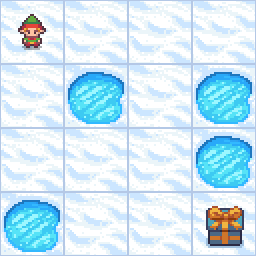

In [4]:
import gym
import numpy as np
import imageio
from IPython.display import HTML
from base64 import b64encode

if __name__ == "__main__":
    # --- 建立環境：啟用隨機滑動 (slippery) ---
    env = gym.make(
        'FrozenLake-v1',
        render_mode='rgb_array',
        is_slippery=True,      # 隨機性：動作可能滑向左右
        map_name="4x4"
    )

    # Value Iteration 訓練
    print("正在執行 Value Iteration (slippery=True) …")
    V, policy = value_iteration(env, gamma=0.95, theta=1e-6)
    print("訓練完成，最優策略 (0:Left,1:Down,2:Right,3:Up)：")
    print(policy)

    # 自動執行最優策略
    print("使用最優策略執行一個 episode …")
    frames, total_reward, done = run_episode_and_capture_frames(env, policy)
    print(f"Episode 結束 → done={done}，總 reward={total_reward}")

    # 輸出並顯示 GIF
    if frames:
        gif_path = create_gif_from_frames(frames, filename = "frozenlake_slippery.gif", fps=4)
        print(f"已儲存 GIF：{gif_path}，以下在 Notebook 中顯示：")
        display_html = display_gif_in_notebook(gif_path)
        display_html  # Notebook 內顯示

    env.close()
